#**Week** 4 Actividad 4: Aplicación de Métodos de Regularización en una Red Neuronal


# Objetivo
Entrenar una red neuronal para clasificar casos de un contact center (FCR vs Escalamiento) y comparar:
1) Modelo base (sin regularización)
2) Modelo con regularización (L2 + Dropout)

Se observará el comportamiento de loss y accuracy en entrenamiento/validación y el desempeño final en test.


# Analogía Contact Center
- Cada fila del dataset = un "caso" que llega al contact center.
- X (variables): duración, transferencias, reincidencia, sentimiento, etc.
- y (etiqueta): 0 = FCR, 1 = Escalamiento.
- Entrenar = capacitar al contact center con casos históricos.
- Loss = error/costo de tipificar mal (reproceso).
- Accuracy = KPI de calidad (porcentaje de aciertos).

# Desarrollo


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2


In [2]:
#Reproducibilidad (obligatorio para “resultados verificables”)

import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


Dataset sintético (casos históricos del contact center)

In [3]:
n = 2500  # total casos

# Variables típicas de un caso en contact center (simuladas)
duracion = np.random.normal(loc=6, scale=2.0, size=n)          # minutos
transferencias = np.random.poisson(lam=1.2, size=n)            # # transfers
reincidencia = np.random.binomial(1, p=0.25, size=n)           # 0/1
sentimiento = np.random.normal(loc=0.0, scale=1.0, size=n)     # -/+
canal_whatsapp = np.random.binomial(1, p=0.35, size=n)         # 0/1
tipo_queja_calidad = np.random.binomial(1, p=0.30, size=n)     # 0/1

# Regla "real" (oculta) para generar la etiqueta (con ruido)
logit = (
    0.55*duracion +
    0.90*transferencias +
    1.30*reincidencia -
    0.70*sentimiento +
    0.60*tipo_queja_calidad +
    0.25*canal_whatsapp
)

# Convertimos a probabilidad
prob = 1 / (1 + np.exp(-(logit - 4.5)))

# Etiqueta: 1 = Escalar, 0 = FCR (con algo de ruido)
y = (np.random.rand(n) < prob).astype(int)

X = np.column_stack([duracion, transferencias, reincidencia, sentimiento, canal_whatsapp, tipo_queja_calidad])

feature_names = ["duracion_min", "transferencias", "reincidencia", "sentimiento", "canal_whatsapp", "queja_calidad"]
df = pd.DataFrame(X, columns=feature_names)
df["y_escalamiento"] = y

df.head()

,duracion_min,transferencias,reincidencia,sentimiento,canal_whatsapp,queja_calidad,y_escalamiento
0,6.993428,2.0,1.0,-0.099314,1.0,0.0,1
1,5.723471,0.0,0.0,-0.272427,1.0,0.0,0
2,7.295377,1.0,0.0,-1.954593,0.0,0.0,0
3,9.046060,1.0,1.0,-0.310397,1.0,1.0,1
4,5.531693,1.0,0.0,0.881062,0.0,0.0,1


Split + escalado (preprocesamiento)

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.60, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "Val:", X_val_s.shape, "Test:", X_test_s.shape)

Train: (1000, 6) Val: (750, 6) Test: (750, 6)


Función para construir el modelo base

In [5]:
def build_base_model(input_dim):
    model = keras.Sequential([
        layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

Función para construir el modelo regularizado (L2 + Dropout)

In [6]:
def build_regularized_model(input_dim, l2_factor=1e-4, dropout_rate=0.35):
    model = keras.Sequential([
        layers.Dense(256, activation="relu", kernel_regularizer=l2(l2_factor), input_shape=(input_dim,)),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation="relu", kernel_regularizer=l2(l2_factor)),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

Función única de entrenamiento (para que sea “justa”)

In [7]:
def train_and_evaluate(model, name, epochs=50, batch_size=32):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    print(f"\n===== Entrenando: {name} =====")
    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    return history, (test_loss, test_acc)

Entrenar Configuración A: Base (sin regularización)

In [8]:
base_model = build_base_model(input_dim=X_train_s.shape[1])
hist_base, res_base = train_and_evaluate(base_model, "Modelo Base (sin regularización)", epochs=60)


===== Entrenando: Modelo Base (sin regularización) =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss: 0.6746 | Test Accuracy: 0.6907


Entrenar Configuración B: Regularizado (L2 + Dropout)

In [9]:
reg_model = build_regularized_model(input_dim=X_train_s.shape[1], l2_factor=1e-4, dropout_rate=0.35)
hist_reg, res_reg = train_and_evaluate(reg_model, "Modelo Regularizado (L2 + Dropout)", epochs=60)



===== Entrenando: Modelo Regularizado (L2 + Dropout) =====
Test Loss: 0.5936 | Test Accuracy: 0.7040


Gráficas (loss y accuracy)

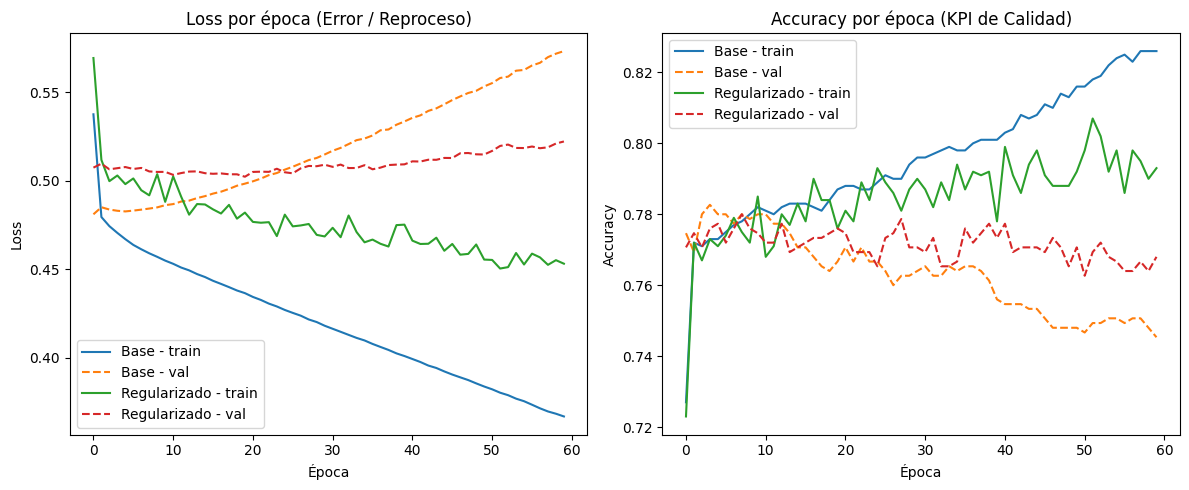

In [10]:
def plot_history(h1, h2, label1="Base", label2="Regularizado"):
    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)
    plt.plot(h1.history["loss"], label=f"{label1} - train")
    plt.plot(h1.history["val_loss"], linestyle="--", label=f"{label1} - val")
    plt.plot(h2.history["loss"], label=f"{label2} - train")
    plt.plot(h2.history["val_loss"], linestyle="--", label=f"{label2} - val")
    plt.title("Loss por época (Error / Reproceso)")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    # ACC
    plt.subplot(1,2,2)
    plt.plot(h1.history["accuracy"], label=f"{label1} - train")
    plt.plot(h1.history["val_accuracy"], linestyle="--", label=f"{label1} - val")
    plt.plot(h2.history["accuracy"], label=f"{label2} - train")
    plt.plot(h2.history["val_accuracy"], linestyle="--", label=f"{label2} - val")
    plt.title("Accuracy por época (KPI de Calidad)")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(hist_base, hist_reg)

Entrenar Configuración A: Base (sin regularización)

In [11]:
base_model = build_base_model(input_dim=X_train_s.shape[1])
hist_base, res_base = train_and_evaluate(base_model, "Modelo Base (sin regularización)", epochs=60)


===== Entrenando: Modelo Base (sin regularización) =====
Test Loss: 0.6779 | Test Accuracy: 0.6827


Entrenar Configuración B: Regularizado (L2 + Dropout)

In [12]:
reg_model = build_regularized_model(input_dim=X_train_s.shape[1], l2_factor=1e-4, dropout_rate=0.35)
hist_reg, res_reg = train_and_evaluate(reg_model, "Modelo Regularizado (L2 + Dropout)", epochs=60)



===== Entrenando: Modelo Regularizado (L2 + Dropout) =====
Test Loss: 0.5957 | Test Accuracy: 0.7027


Gráficas (loss y accuracy)

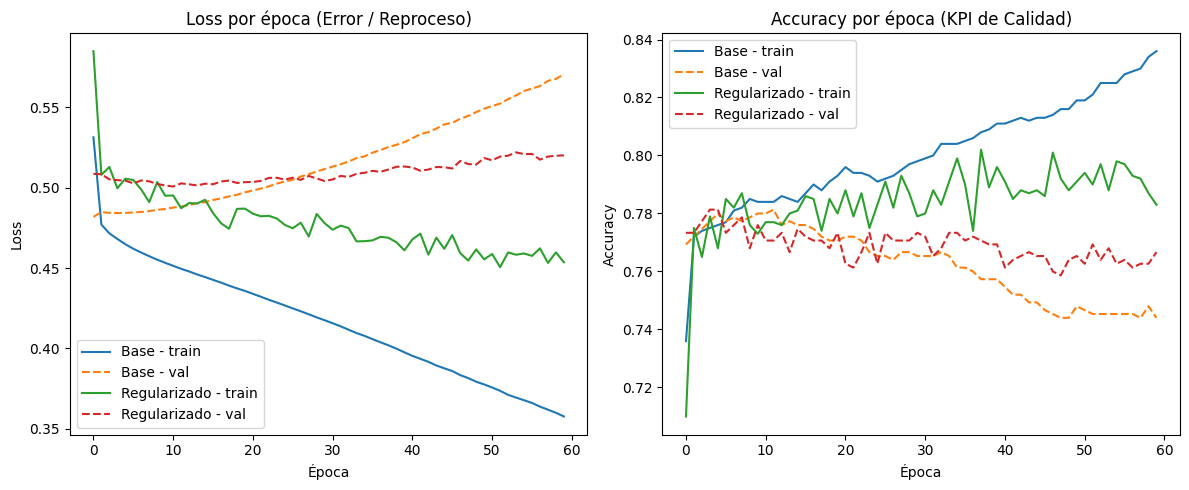

In [13]:
def plot_history(h1, h2, label1="Base", label2="Regularizado"):
    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)
    plt.plot(h1.history["loss"], label=f"{label1} - train")
    plt.plot(h1.history["val_loss"], linestyle="--", label=f"{label1} - val")
    plt.plot(h2.history["loss"], label=f"{label2} - train")
    plt.plot(h2.history["val_loss"], linestyle="--", label=f"{label2} - val")
    plt.title("Loss por época (Error / Reproceso)")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    # ACC
    plt.subplot(1,2,2)
    plt.plot(h1.history["accuracy"], label=f"{label1} - train")
    plt.plot(h1.history["val_accuracy"], linestyle="--", label=f"{label1} - val")
    plt.plot(h2.history["accuracy"], label=f"{label2} - train")
    plt.plot(h2.history["val_accuracy"], linestyle="--", label=f"{label2} - val")
    plt.title("Accuracy por época (KPI de Calidad)")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(hist_base, hist_reg)

Tabla comparativa final (métrica de evaluación)

In [14]:
df_results = pd.DataFrame({
    "Configuración": ["Base (sin regularización)", "Regularizado (L2 + Dropout)"],
    "Test Loss": [res_base[0], res_reg[0]],
    "Test Accuracy": [res_base[1], res_reg[1]]
})
df_results

,Configuración,Test Loss,Test Accuracy
0,Base (sin regularización),0.677902,0.682667
1,Regularizado (L2 + Dropout),0.595671,0.702667


## Conclusiones

Evidencia de overfitting / underfitting
- Si el loss de entrenamiento baja mucho y la accuracy de entrenamiento sube, pero el val_loss deja de bajar o sube y la val_accuracy se estanca, hay overfitting.
- Si tanto entrenamiento como validación son malos y no mejoran, sería underfitting (modelo muy simple o entrenamiento insuficiente).

Efecto de la regularización (L2 + Dropout)
- **L2** penaliza pesos grandes, forzando una solución más simple.
- **Dropout** evita que el modelo dependa demasiado de neuronas específicas.
- En los resultados, lo esperado es:
  - Curvas de validación más estables
  - Menor brecha entre train y val
  - Mejor generalización en test (o pérdida menor, aunque a veces baja un poco la accuracy de train)

Hallazgos o dificultades

- Mantener todo constante fue clave para una comparación justa (misma arquitectura base, mismo dataset, mismas épocas).
- Ajustar hiperparámetros (dropout_rate, l2_factor) puede cambiar el balance entre estabilidad y desempeño.
- La interpretación se apoya en observar las curvas y la tabla final.